# MiniGrid：跨 seed 的 WM target loss 与 policy 分布

本 notebook 完全自包含，只读取已有 CSV；不会导入或生成任何 `.py` 文件，也不会启动训练。Policy 与 changed-focal 对比图同时保存为 PNG。

In [1]:
%matplotlib inline
from pathlib import Path
import csv
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# NeurIPS-style, paper-ready defaults (the plot is still displayed inline).
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.7,
    'lines.linewidth': 1.1,
    'figure.dpi': 140,
})

DR_REL = Path('outputs/results/dr/dr_summary_minigrid_mask5_focal_reservoir.csv')
MAC_REL = Path('outputs/results/mac/minigrid_ued_results_mask5_focal_reservoir_sa.csv')
P2E_REL = Path('outputs/results/p2e/p2e_baseline_minigrid_mask5_n28580_m1_summary.csv')
TARGET_BASELINE_REL = Path('outputs/results/target_baseline/target_baseline_minigrid_mask5.csv')
POLICY_REL = Path('outputs/results/dr_policy_target_eval/policy_target_summary.csv')
REQUIRED_RESULTS = (DR_REL, MAC_REL, P2E_REL, TARGET_BASELINE_REL, POLICY_REL)
REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                   if all((p / rel).is_file() for rel in REQUIRED_RESULTS)), None)
if REPO_ROOT is None:
    raise FileNotFoundError(
        '找不到当前 workspace 的结果 CSV。请从 Curriculum_world_model_learning 根目录打开 notebook。'
    )
DR_LOSS_CSV = REPO_ROOT / DR_REL
MAC_LOSS_CSV = REPO_ROOT / MAC_REL
P2E_LOSS_CSV = REPO_ROOT / P2E_REL
TARGET_BASELINE_LOSS_CSV = REPO_ROOT / TARGET_BASELINE_REL
POLICY_SUMMARY_CSV = REPO_ROOT / POLICY_REL
print('Repository:', REPO_ROOT)
print('DR CSV:', DR_LOSS_CSV)
print('MAC CSV:', MAC_LOSS_CSV)
print('P2E CSV:', P2E_LOSS_CSV)
print('Target baseline CSV:', TARGET_BASELINE_LOSS_CSV)
print('Policy summary CSV:', POLICY_SUMMARY_CSV)

Repository: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning
DR CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/dr/dr_summary_minigrid_mask5_focal_reservoir.csv
MAC CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/mac/minigrid_ued_results_mask5_focal_reservoir_sa.csv
P2E CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/p2e/p2e_baseline_minigrid_mask5_n28580_m1_summary.csv
Target baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/target_baseline/target_baseline_minigrid_mask5.csv
Policy summary CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/dr_policy_target_eval/policy_target_summary.csv


## 1. WM target validation loss：DR、Target Random 与 P2E（mean ± std）

横轴统一为累计训练 transitions：DR 累加 `New_Data_Size`，Target Random 使用 `cumulative_data_size`，P2E 使用 `transitions`。

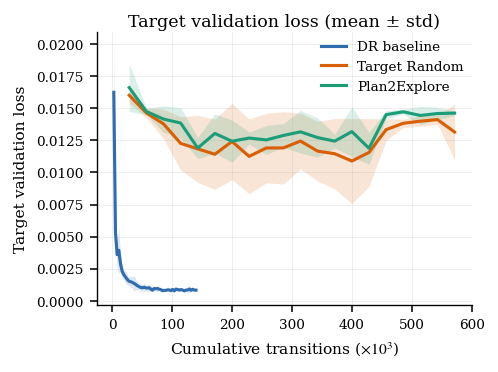

In [2]:
baseline_specs = [
    {
        'name': 'DR baseline',
        'path': DR_LOSS_CSV,
        'seed_col': 'Seed',
        'loss_col': 'target_val_avg_val_loss_wm',
        'data_col': 'New_Data_Size',
        'data_is_increment': True,
        'color': '#2F6DAE',
    },
    {
        'name': 'Target Random',
        'path': TARGET_BASELINE_LOSS_CSV,
        'seed_col': 'Seed',
        'loss_col': 'target_val_avg_val_loss_wm',
        'data_col': 'cumulative_data_size',
        'data_is_increment': False,
        'color': '#D95F02',
    },
    {
        'name': 'Plan2Explore',
        'path': P2E_LOSS_CSV,
        'seed_col': 'seed',
        'loss_col': 'avg_target_loss',
        'data_col': 'transitions',
        'data_is_increment': False,
        'color': '#1B9E77',
    },
]

def load_seed_loss_curves(spec):
    with spec['path'].open(encoding='utf-8', newline='') as f:
        rows = list(csv.DictReader(f))
    seed_rows = defaultdict(list)
    for row in rows:
        seed = int(row[spec['seed_col']])
        iteration = int(row['Iter'])
        data_value = float(row[spec['data_col']])
        loss = float(row[spec['loss_col']])
        seed_rows[seed].append((iteration, data_value, loss))
    grouped = {}
    for seed, values in seed_rows.items():
        cumulative = 0.0
        grouped[seed] = {}
        for _, data_value, loss in sorted(values):
            if spec['data_is_increment']:
                cumulative += data_value
            else:
                cumulative = data_value
            grouped[seed][int(round(cumulative))] = loss
    if not grouped:
        raise ValueError(f"No rows found for {spec['name']}")
    common_data = sorted(set.intersection(*(set(v) for v in grouped.values())))
    if not common_data:
        raise ValueError(f"No common cumulative data points across seeds for {spec['name']}")
    matrix = np.asarray([[grouped[s][x] for x in common_data]
                         for s in sorted(grouped)], dtype=float)
    mean = matrix.mean(axis=0)
    std = matrix.std(axis=0, ddof=1) if matrix.shape[0] > 1 else np.zeros_like(mean)
    return common_data, matrix, mean, std

baseline_stats = {}
fig, ax = plt.subplots(figsize=(3.45, 2.55), dpi=140)
for spec in baseline_specs:
    common_data, matrix, mean, std = load_seed_loss_curves(spec)
    baseline_stats[spec['name']] = {
        'seed_count': int(matrix.shape[0]),
        'iteration_count': int(matrix.shape[1]),
        'last_cumulative_transitions': int(common_data[-1]),
        'first_mean_loss': float(mean[0]),
        'last_mean_loss': float(mean[-1]),
        'last_std_loss': float(std[-1]),
    }
    data_thousands = np.asarray(common_data, dtype=float) / 1000.0
    ax.plot(data_thousands, mean, color=spec['color'], linewidth=1.6,
            label=spec['name'])
    ax.fill_between(data_thousands, mean - std, mean + std,
                    color=spec['color'], alpha=0.16, linewidth=0,
                    label='_nolegend_')
ax.set_title('Target validation loss (mean ± std)', pad=3)
ax.set_xlabel(r'Cumulative transitions ($\times 10^3$)')
ax.set_ylabel('Target validation loss')
ax.grid(True, alpha=0.22, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, handlelength=1.8, borderaxespad=0.2)
fig.tight_layout(pad=0.4)
plt.show()

In [3]:
display({
    name: stats for name, stats in baseline_stats.items()
})

{'DR baseline': {'seed_count': 5,
  'iteration_count': 50,
  'last_cumulative_transitions': 140000,
  'first_mean_loss': 0.016243172697722914,
  'last_mean_loss': 0.0008416790253249929,
  'last_std_loss': 5.40166588681281e-05},
 'Target Random': {'seed_count': 5,
  'iteration_count': 20,
  'last_cumulative_transitions': 571600,
  'first_mean_loss': 0.016008094125427304,
  'last_mean_loss': 0.013148156842216851,
  'last_std_loss': 0.0021614277722241666},
 'Plan2Explore': {'seed_count': 5,
  'iteration_count': 20,
  'last_cumulative_transitions': 571600,
  'first_mean_loss': 0.01660619900561869,
  'last_mean_loss': 0.014620613786391914,
  'last_std_loss': 0.0001831908942777132}}

## 2. Policy 验证结果：四种方法的 policy-run 均值 ± 标准差

严格按照 summary CSV 的每一行统计和绘图：每个黑点对应一个 `(method, target, wm_seed, policy_seed)` policy run。DR/MAC 每个 target 有 8 条记录，P2E/Target Random 有 5 条。Dense reward 是 shaped reward，success rate 是主要结果。

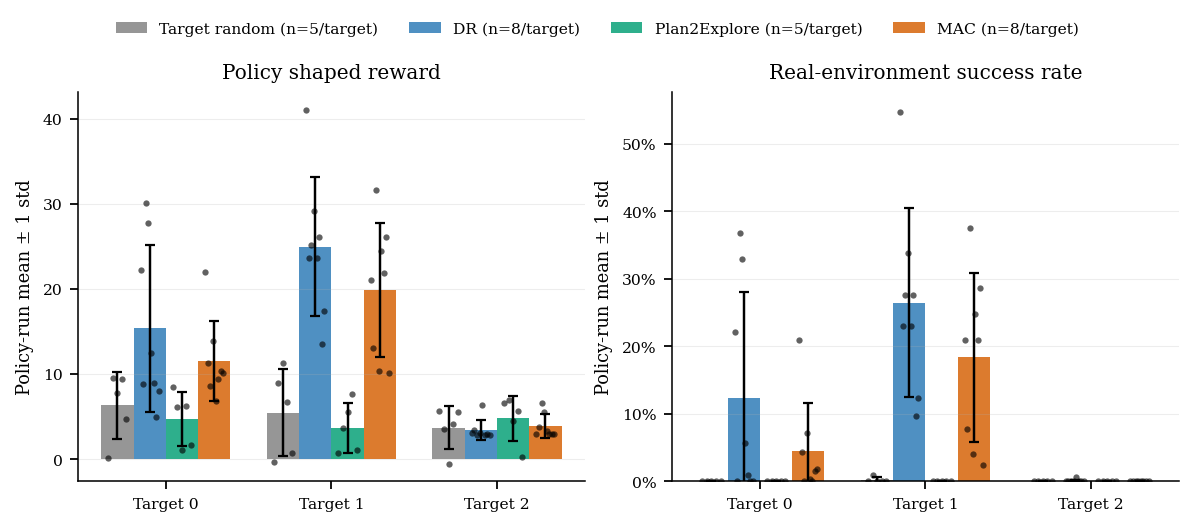

Saved: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/plots/seed_comparison/policy_baseline_comparison.png
Plotted policy-run rows: 78


In [4]:
from matplotlib.ticker import PercentFormatter

policy_df = pd.read_csv(POLICY_SUMMARY_CSV).copy()
required_policy_cols = {
    'method', 'wm_seed', 'policy_seed', 'target', 'mean_reward',
    'success_rate', 'goal_dist_mean', 'goal_dist_min',
}
missing = sorted(required_policy_cols - set(policy_df.columns))
if missing:
    raise ValueError(f'Policy summary is missing columns: {missing}')
metric_cols = ['mean_reward', 'success_rate', 'goal_dist_mean', 'goal_dist_min']
for col in ['wm_seed', 'policy_seed', *metric_cols]:
    policy_df[col] = pd.to_numeric(policy_df[col], errors='coerce')
policy_df['method'] = policy_df['method'].str.lower()
policy_df = policy_df.dropna(subset=['method', 'wm_seed', 'policy_seed', 'target', *metric_cols])
run_keys = ['method', 'wm_seed', 'policy_seed', 'target']
duplicate_count = int(policy_df.duplicated(run_keys, keep=False).sum())
if duplicate_count:
    print(f'Warning: keeping the last of {duplicate_count} duplicate policy-run rows')
    policy_df = policy_df.drop_duplicates(run_keys, keep='last')

# Direct CSV-row aggregation: every distinct policy run receives one point.
policy_summary = (policy_df.groupby(['method', 'target'])
                  .agg(policy_run_count=('policy_seed', 'size'),
                       wm_seed_count=('wm_seed', 'nunique'),
                       mean_reward=('mean_reward', 'mean'),
                       std_reward=('mean_reward', 'std'),
                       success_rate=('success_rate', 'mean'),
                       std_success_rate=('success_rate', 'std'),
                       goal_dist_mean=('goal_dist_mean', 'mean'),
                       goal_dist_min=('goal_dist_min', 'mean'))
                  .reset_index())
policy_summary[['std_reward', 'std_success_rate']] = (
    policy_summary[['std_reward', 'std_success_rate']].fillna(0.0)
)

preferred_methods = ['target', 'dr', 'p2e', 'mac']
methods = [m for m in preferred_methods if m in set(policy_df['method'])]
methods += sorted(set(policy_df['method']) - set(methods))
method_labels = {'target': 'Target random', 'dr': 'DR', 'p2e': 'Plan2Explore', 'mac': 'MAC'}
method_colors = {'target': '#7F7F7F', 'dr': '#2878B5', 'p2e': '#009E73', 'mac': '#D55E00'}
targets = sorted(policy_df['target'].unique(), key=lambda value: int(value.replace('target_task', '')))
target_labels = [target.replace('target_task', 'Target ') for target in targets]
summary_index = policy_summary.set_index(['method', 'target'])
x = np.arange(len(targets), dtype=float)
width = 0.78 / len(methods)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.15), dpi=160)
for method_idx, method in enumerate(methods):
    offset = (method_idx - (len(methods) - 1) / 2.0) * width
    method_stats = summary_index.loc[method]
    reward_mean = np.asarray([method_stats.loc[t, 'mean_reward'] for t in targets])
    reward_std = np.asarray([method_stats.loc[t, 'std_reward'] for t in targets])
    success_mean = np.asarray([method_stats.loc[t, 'success_rate'] for t in targets])
    success_std = np.asarray([method_stats.loc[t, 'std_success_rate'] for t in targets])
    run_counts = method_stats['policy_run_count'].astype(int).to_numpy()
    run_label = str(run_counts[0]) if np.all(run_counts == run_counts[0]) else f'{run_counts.min()}–{run_counts.max()}'
    centers = x + offset
    axes[0].bar(centers, reward_mean, width=width, yerr=reward_std, capsize=2.2,
                color=method_colors.get(method), alpha=0.82,
                label=f'{method_labels.get(method, method)} (n={run_label}/target)')
    axes[1].bar(centers, success_mean, width=width, yerr=success_std, capsize=2.2,
                color=method_colors.get(method), alpha=0.82)
    for target_idx, target in enumerate(targets):
        run_rows = policy_df[(policy_df['method'] == method) & (policy_df['target'] == target)]
        jitter = np.linspace(-0.28 * width, 0.28 * width, len(run_rows))
        axes[0].scatter(centers[target_idx] + jitter, run_rows['mean_reward'],
                        s=8, color='black', alpha=0.62, linewidths=0, zorder=3)
        axes[1].scatter(centers[target_idx] + jitter, run_rows['success_rate'],
                        s=8, color='black', alpha=0.62, linewidths=0, zorder=3)

axes[0].set_title('Policy shaped reward')
axes[0].set_ylabel('Policy-run mean ± 1 std')
axes[1].set_title('Real-environment success rate')
axes[1].set_ylabel('Policy-run mean ± 1 std')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_ylim(bottom=0.0)
for ax in axes:
    ax.set_xticks(x, target_labels)
    ax.grid(axis='y', alpha=0.22, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center', ncol=len(methods),
           frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.93), pad=0.6)

POLICY_FIG_DIR = REPO_ROOT / 'outputs/results/plots/seed_comparison'
POLICY_FIG_DIR.mkdir(parents=True, exist_ok=True)
POLICY_FIG = POLICY_FIG_DIR / 'policy_baseline_comparison.png'
POLICY_FIG_LEGACY = POLICY_FIG_DIR / 'policy_seed_std_bar.png'
fig.savefig(POLICY_FIG, dpi=300, bbox_inches='tight')
fig.savefig(POLICY_FIG_LEGACY, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', POLICY_FIG)
print('Plotted policy-run rows:', len(policy_df))

In [5]:
display(policy_summary.sort_values(['target', 'method']).reset_index(drop=True))

,method,target,policy_run_count,wm_seed_count,mean_reward,std_reward,success_rate,std_success_rate,goal_dist_mean,goal_dist_min
0,dr,target_task0,8,5,15.431441,9.805411,0.123375,0.157998,27.633944,13.784625
1,mac,target_task0,8,5,11.589054,4.689006,0.045250,0.071061,27.123751,13.583375
2,p2e,target_task0,5,5,4.748502,3.225174,0.000000,0.000000,41.164340,32.868000
3,target,target_task0,5,5,6.336374,3.944715,0.000000,0.000000,36.181691,26.694000
4,dr,target_task1,8,5,24.995457,8.194074,0.264875,0.139653,49.134715,18.446875
5,mac,target_task1,8,5,19.881716,7.897475,0.184000,0.125268,51.103184,23.052625
6,p2e,target_task1,5,5,3.740642,2.931978,0.000000,0.000000,61.980388,53.806000
7,target,target_task1,5,5,5.511174,5.124840,0.002000,0.004472,59.705602,46.304000
8,dr,target_task2,8,5,3.446960,1.207822,0.000750,0.002121,47.743836,43.414125
9,mac,target_task2,8,5,3.910099,1.424845,0.000000,0.000000,46.613493,40.857375


## 3. 诊断图：全部 baseline + DR 最差 5 runs + MAC 最好 5 runs

为匹配 P2E/Target Random 的 5 个 runs，DR/MAC 从各自的 8 个冗余 policy runs 中各选择 5 个。选择单位是跨三个 targets 保持一致的 `(wm_seed, policy_seed)`；先计算其 target 0–2 平均 `success_rate`，DR 取最低 5 个，MAC 取最高 5 个。该图属于选择性诊断，不能替代第 2 节的全量结果。

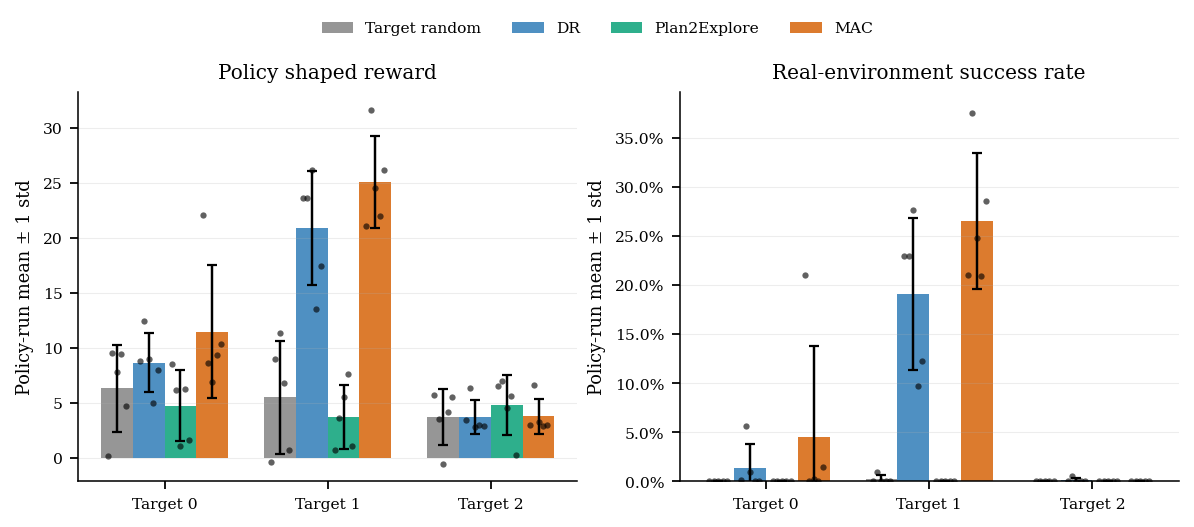

DR selected (wm_seed, policy_seed): [(1, 0), (1, 2), (2, 2), (0, 2), (0, 1)]
MAC selected (wm_seed, policy_seed): [(0, 0), (3, 3), (1, 0), (0, 1), (0, 2)]
Saved: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/plots/seed_comparison/policy_baseline_selected5_comparison.png


,method,wm_seed,policy_seed,mean_reward,success_rate,goal_dist_mean,goal_dist_min,selection
0,dr,1,0,7.192616,0.032333,47.578640,36.183333,DR worst 5
1,dr,1,2,9.448406,0.041000,41.117353,27.967667,DR worst 5
2,dr,2,2,11.968221,0.077000,39.883957,24.277333,DR worst 5
3,dr,0,2,12.641206,0.095667,42.184302,26.212333,DR worst 5
4,dr,0,1,14.161699,0.097667,39.995784,20.000667,DR worst 5
5,mac,0,0,15.378792,0.140000,40.159018,24.985667,MAC best 5
6,mac,3,3,15.659693,0.125333,37.998983,18.078000,MAC best 5
7,mac,1,0,13.189060,0.100333,41.020211,25.454667,MAC best 5
8,mac,0,1,11.581457,0.083667,44.217273,28.451333,MAC best 5
9,mac,0,2,11.440122,0.069667,41.470426,25.911000,MAC best 5


In [6]:
policy_run_ranking = (
    policy_df[policy_df['method'].isin(['dr', 'mac'])]
    .groupby(['method', 'wm_seed', 'policy_seed'], as_index=False)[metric_cols]
    .mean()
)
dr_selected_runs = (policy_run_ranking[policy_run_ranking['method'] == 'dr']
                    .sort_values(['success_rate', 'mean_reward', 'wm_seed', 'policy_seed'],
                                 ascending=[True, True, True, True]).head(5))
mac_selected_runs = (policy_run_ranking[policy_run_ranking['method'] == 'mac']
                     .sort_values(['success_rate', 'mean_reward', 'wm_seed', 'policy_seed'],
                                  ascending=[False, False, True, True]).head(5))
selected5_parts = [policy_df[policy_df['method'].isin(['target', 'p2e'])].copy()]
for selected_runs in [dr_selected_runs, mac_selected_runs]:
    method = selected_runs['method'].iloc[0]
    selected5_parts.append(
        policy_df[policy_df['method'] == method].merge(
            selected_runs[['wm_seed', 'policy_seed']], on=['wm_seed', 'policy_seed'], how='inner'
        )
    )
selected5_policy = pd.concat(selected5_parts, ignore_index=True)
selected5_counts = selected5_policy.groupby(['method', 'target']).size()
if set(selected5_counts.tolist()) != {5}:
    raise ValueError(f'Expected five runs per method/target, got: {selected5_counts.to_dict()}')
selected5_summary = (selected5_policy.groupby(['method', 'target'])
                     .agg(mean_reward=('mean_reward', 'mean'),
                          std_reward=('mean_reward', 'std'),
                          success_rate=('success_rate', 'mean'),
                          std_success_rate=('success_rate', 'std'))
                     .reset_index().set_index(['method', 'target']))
selected5_labels = {
    'target': 'Target random', 'dr': 'DR',
    'p2e': 'Plan2Explore', 'mac': 'MAC',
}

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.15), dpi=160)
for method_idx, method in enumerate(methods):
    offset = (method_idx - (len(methods) - 1) / 2.0) * width
    method_stats = selected5_summary.loc[method]
    reward_mean = np.asarray([method_stats.loc[t, 'mean_reward'] for t in targets])
    reward_std = np.asarray([method_stats.loc[t, 'std_reward'] for t in targets])
    success_mean = np.asarray([method_stats.loc[t, 'success_rate'] for t in targets])
    success_std = np.asarray([method_stats.loc[t, 'std_success_rate'] for t in targets])
    centers = x + (method_idx - (len(methods) - 1) / 2.0) * width
    axes[0].bar(centers, reward_mean, width=width, yerr=reward_std, capsize=2.2,
                color=method_colors.get(method), alpha=0.82, label=selected5_labels[method])
    axes[1].bar(centers, success_mean, width=width, yerr=success_std, capsize=2.2,
                color=method_colors.get(method), alpha=0.82)
    for target_idx, target in enumerate(targets):
        points = selected5_policy[(selected5_policy['method'] == method) &
                                  (selected5_policy['target'] == target)]
        jitter = np.linspace(-0.28 * width, 0.28 * width, len(points))
        axes[0].scatter(centers[target_idx] + jitter, points['mean_reward'],
                        s=8, color='black', alpha=0.62, linewidths=0, zorder=3)
        axes[1].scatter(centers[target_idx] + jitter, points['success_rate'],
                        s=8, color='black', alpha=0.62, linewidths=0, zorder=3)

axes[0].set_title('Policy shaped reward')
axes[0].set_ylabel('Policy-run mean ± 1 std')
axes[1].set_title('Real-environment success rate')
axes[1].set_ylabel('Policy-run mean ± 1 std')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_ylim(bottom=0.0)
for ax in axes:
    ax.set_xticks(x, target_labels)
    ax.grid(axis='y', alpha=0.22, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center', ncol=len(methods),
           frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.93), pad=0.6)
SELECTED5_POLICY_FIG = POLICY_FIG_DIR / 'policy_baseline_selected5_comparison.png'
fig.savefig(SELECTED5_POLICY_FIG, dpi=300, bbox_inches='tight')
plt.show()
print('DR selected (wm_seed, policy_seed):',
      list(map(tuple, dr_selected_runs[['wm_seed', 'policy_seed']].astype(int).to_numpy())))
print('MAC selected (wm_seed, policy_seed):',
      list(map(tuple, mac_selected_runs[['wm_seed', 'policy_seed']].astype(int).to_numpy())))
print('Saved:', SELECTED5_POLICY_FIG)
display(pd.concat([dr_selected_runs.assign(selection='DR worst 5'),
                   mac_selected_runs.assign(selection='MAC best 5')], ignore_index=True))

## 4. 诊断图：DR 最差 3 个 WM seed vs MAC 最好 3 个 WM seed

选择标准为：先在每个 `(method, wm_seed, target)` 内平均 policy seed，再对 target 0–2 的 `success_rate` 求平均。DR 取最低 3 个 WM seed，MAC 取最高 3 个。该图是有意挑选极端 seed 的诊断图，不能替代上方全部运行的公平比较。

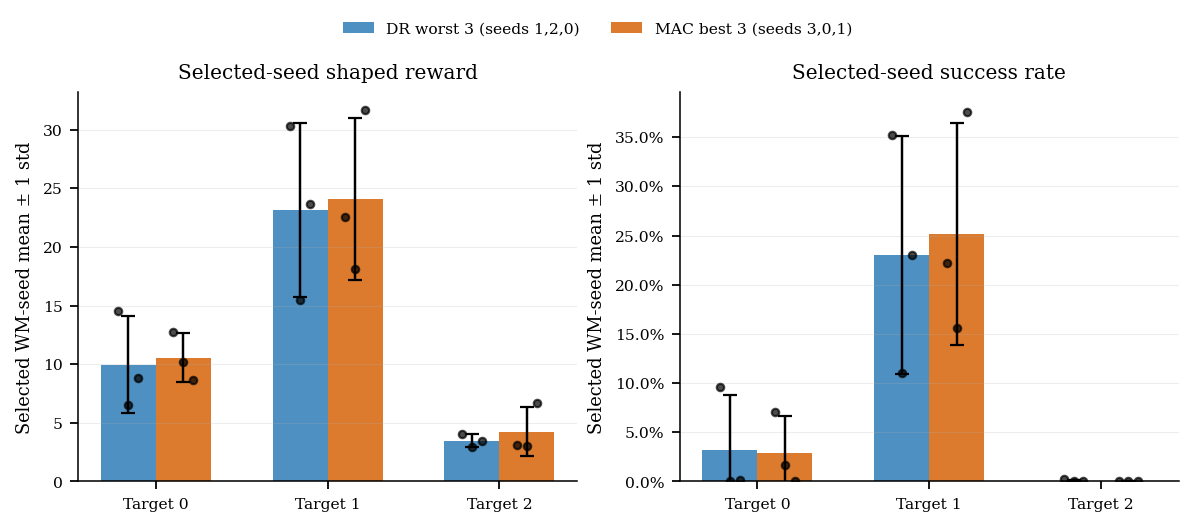

DR worst 3 WM seeds: [1, 2, 0]
MAC best 3 WM seeds: [3, 0, 1]
Saved: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/plots/seed_comparison/policy_dr_worst3_mac_best3.png


,method,wm_seed,mean_reward,success_rate,goal_dist_mean,goal_dist_min,selection
0,dr,1,8.320511,0.036667,44.347997,32.075500,DR rank: low to high
1,dr,2,11.968221,0.077000,39.883957,24.277333,DR rank: low to high
2,dr,0,16.314606,0.149889,40.594239,22.413556,DR rank: low to high
3,dr,3,19.412994,0.214667,40.935767,23.565000,DR rank: low to high
4,dr,4,20.030902,0.222667,40.734887,22.487667,DR rank: low to high
5,mac,3,15.659693,0.125333,37.998983,18.078000,MAC rank: high to low
6,mac,0,12.800123,0.097778,41.948906,26.449333,MAC rank: high to low
7,mac,1,10.453979,0.057500,42.624197,27.900500,MAC rank: high to low
8,mac,2,9.396593,0.040000,43.499222,28.018000,MAC rank: high to low
9,mac,4,9.984370,0.037667,40.314491,25.404000,MAC rank: high to low


In [7]:
wm_policy_for_selection = (
    policy_df[policy_df['method'].isin(['dr', 'mac'])]
    .groupby(['method', 'wm_seed', 'target'], as_index=False)[metric_cols]
    .mean()
)
seed_ranking = (wm_policy_for_selection.groupby(['method', 'wm_seed'], as_index=False)[metric_cols]
                .mean())
if seed_ranking.groupby('method')['wm_seed'].nunique().min() < 3:
    raise ValueError('Need at least three WM seeds for both DR and MAC')
dr_ranking = seed_ranking[seed_ranking['method'] == 'dr'].sort_values(
    ['success_rate', 'mean_reward', 'wm_seed'], ascending=[True, True, True]
)
mac_ranking = seed_ranking[seed_ranking['method'] == 'mac'].sort_values(
    ['success_rate', 'mean_reward', 'wm_seed'], ascending=[False, False, True]
)
dr_worst_seeds = dr_ranking.head(3)['wm_seed'].astype(int).tolist()
mac_best_seeds = mac_ranking.head(3)['wm_seed'].astype(int).tolist()
selection_specs = [
    {'method': 'dr', 'label': 'DR worst 3', 'seeds': dr_worst_seeds, 'color': '#2878B5'},
    {'method': 'mac', 'label': 'MAC best 3', 'seeds': mac_best_seeds, 'color': '#D55E00'},
]
selected_parts = []
for spec in selection_specs:
    part = wm_policy_for_selection[(wm_policy_for_selection['method'] == spec['method']) &
                                   (wm_policy_for_selection['wm_seed'].isin(spec['seeds']))].copy()
    part['selection'] = spec['label']
    selected_parts.append(part)
selected_policy = pd.concat(selected_parts, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.15), dpi=160)
selected_width = 0.32
for method_idx, spec in enumerate(selection_specs):
    offset = (method_idx - 0.5) * selected_width
    method_rows = selected_policy[selected_policy['selection'] == spec['label']]
    method_summary = method_rows.groupby('target')[['mean_reward', 'success_rate']].agg(['mean', 'std'])
    centers = x + offset
    reward_mean = np.asarray([method_summary.loc[t, ('mean_reward', 'mean')] for t in targets])
    reward_std = np.asarray([method_summary.loc[t, ('mean_reward', 'std')] for t in targets])
    success_mean = np.asarray([method_summary.loc[t, ('success_rate', 'mean')] for t in targets])
    success_std = np.asarray([method_summary.loc[t, ('success_rate', 'std')] for t in targets])
    axes[0].bar(centers, reward_mean, width=selected_width, yerr=reward_std, capsize=3,
                color=spec['color'], alpha=0.82,
                label=f"{spec['label']} (seeds {','.join(map(str, spec['seeds']))})")
    axes[1].bar(centers, success_mean, width=selected_width, yerr=success_std, capsize=3,
                color=spec['color'], alpha=0.82)
    for target_idx, target in enumerate(targets):
        points = method_rows[method_rows['target'] == target].sort_values('wm_seed')
        jitter = np.linspace(-0.18 * selected_width, 0.18 * selected_width, len(points))
        point_x = centers[target_idx] + jitter
        axes[0].scatter(point_x, points['mean_reward'], s=11, color='black', alpha=0.7, zorder=3)
        axes[1].scatter(point_x, points['success_rate'], s=11, color='black', alpha=0.7, zorder=3)

axes[0].set_title('Selected-seed shaped reward')
axes[0].set_ylabel('Selected WM-seed mean ± 1 std')
axes[1].set_title('Selected-seed success rate')
axes[1].set_ylabel('Selected WM-seed mean ± 1 std')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_ylim(bottom=0.0)
for ax in axes:
    ax.set_xticks(x, target_labels)
    ax.grid(axis='y', alpha=0.22, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center', ncol=2,
           frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.93), pad=0.6)
SELECTED_POLICY_FIG = POLICY_FIG_DIR / 'policy_dr_worst3_mac_best3.png'
fig.savefig(SELECTED_POLICY_FIG, dpi=300, bbox_inches='tight')
plt.show()
print('DR worst 3 WM seeds:', dr_worst_seeds)
print('MAC best 3 WM seeds:', mac_best_seeds)
print('Saved:', SELECTED_POLICY_FIG)
display(pd.concat([dr_ranking.assign(selection='DR rank: low to high'),
                   mac_ranking.assign(selection='MAC rank: high to low')], ignore_index=True))

## 5. MAC vs DR：warmup 后的 changed-focal 趋势

DR 的 Iter 1 和 MAC warmup 后的 Iter 11 都对齐到横轴 0。只比较 `target_val_changed_focal_loss`；实线/虚线为跨 seed 均值，阴影为 ±1 标准差，浅线为单个 seed。

Using seeds [0, 1, 2, 3, 4], aligned iterations 0-49


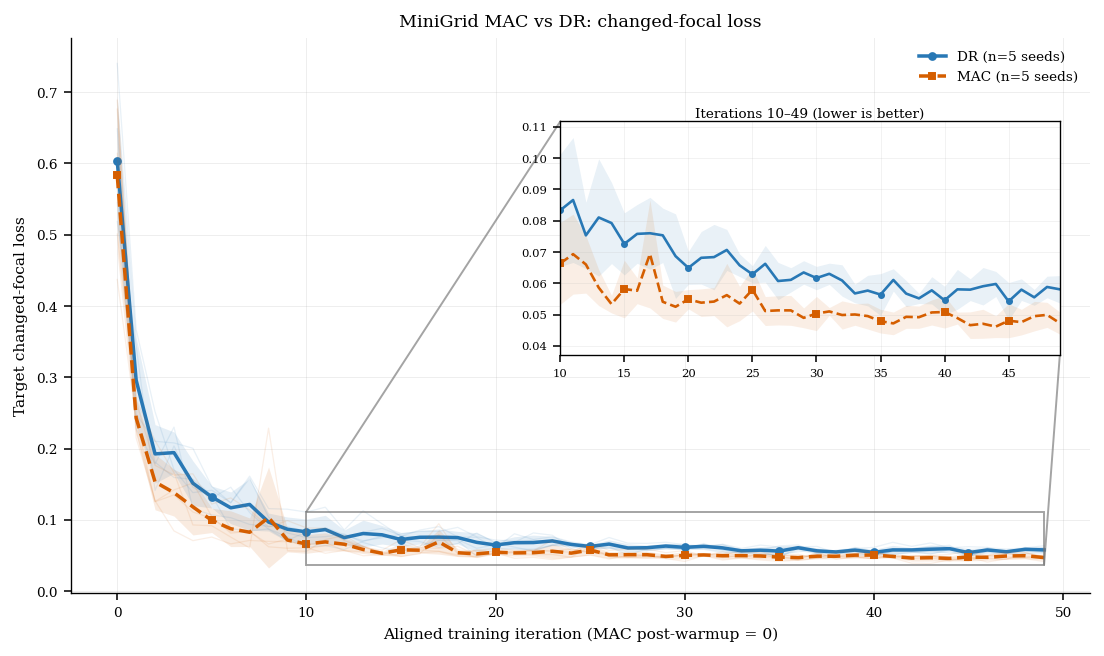

Saved: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/mac_dr_changed_focal_across_seeds.png


original_iter_min  original_iter_max  aligned_start  aligned_end  \
Method Seed                                                                     
DR     0                     1                 50              0           49   
       1                     1                 50              0           49   
       2                     1                 50              0           49   
       3                     1                 50              0           49   
       4                     1                 50              0           49   
MAC    0                    11                 60              0           49   
       1                    11                 60              0           49   
       2                    11                 60              0           49   
       3                    11                 60              0           49   
       4                    11                 60              0           49   

             count  
Method Seed         
DR     0        50  
       1        50  
       2        50  
       3        50  
       4        50  
MAC    0        50  
       1        50  
       2        50  
       3        50  
       4        50

In [8]:
CHANGED_FOCAL = 'target_val_changed_focal_loss'
MAC_WARMUP_ITER = 10
COMPARISON_SEEDS = [0, 1, 2, 3, 4]

def load_changed_focal(path, method, warmup_iter=0):
    df = pd.read_csv(path).copy()
    for col in ['Seed', 'Iter', CHANGED_FOCAL]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['Seed', 'Iter', CHANGED_FOCAL])
    if 'target_val_valid_count' in df.columns:
        valid = pd.to_numeric(df['target_val_valid_count'], errors='coerce')
        df = df[valid > 0].copy()
    df = (df.sort_values(['Seed', 'Iter'])
            .drop_duplicates(['Seed', 'Iter'], keep='last'))
    df = df[df['Iter'] > warmup_iter].copy()
    df['Aligned_Iter'] = df.groupby('Seed').cumcount()
    df['Method'] = method
    return df

dr_changed = load_changed_focal(DR_LOSS_CSV, 'DR')
mac_changed = load_changed_focal(MAC_LOSS_CSV, 'MAC', MAC_WARMUP_ITER)
dr_changed = dr_changed[dr_changed['Seed'].isin(COMPARISON_SEEDS)].copy()
mac_changed = mac_changed[mac_changed['Seed'].isin(COMPARISON_SEEDS)].copy()
for name, frame in [('DR', dr_changed), ('MAC', mac_changed)]:
    missing = sorted(set(COMPARISON_SEEDS) - set(frame['Seed'].astype(int)))
    if missing:
        raise ValueError(f'{name} is missing comparison seeds: {missing}')
changed_data = pd.concat([dr_changed, mac_changed], ignore_index=True)
common_end = int(changed_data.groupby(['Method', 'Seed'])['Aligned_Iter'].max().min())
changed_data = changed_data[changed_data['Aligned_Iter'] <= common_end].copy()
print(f'Using seeds {COMPARISON_SEEDS}, aligned iterations 0-{common_end}')

styles = {
    'DR': {'color': '#2878B5', 'linestyle': '-', 'marker': 'o'},
    'MAC': {'color': '#D55E00', 'linestyle': '--', 'marker': 's'},
}
fig, ax = plt.subplots(figsize=(7.8, 4.6))
summary_stats = {}
for method in ['DR', 'MAC']:
    method_df = changed_data[changed_data['Method'] == method]
    style = styles[method]
    for _, seed_df in method_df.groupby('Seed'):
        seed_df = seed_df.sort_values('Aligned_Iter')
        ax.plot(seed_df['Aligned_Iter'], seed_df[CHANGED_FOCAL],
                color=style['color'], alpha=0.10, linewidth=0.65)
    stats = (method_df.groupby('Aligned_Iter')[CHANGED_FOCAL]
             .agg(['mean', 'std']).reset_index().sort_values('Aligned_Iter'))
    stats['std'] = stats['std'].fillna(0.0)
    summary_stats[method] = stats
    x = stats['Aligned_Iter'].to_numpy()
    mean = stats['mean'].to_numpy()
    std = stats['std'].to_numpy()
    ax.plot(x, mean, color=style['color'], linestyle=style['linestyle'],
            marker=style['marker'], markevery=5, markersize=3.5, linewidth=1.8,
            label=f"{method} (n={method_df['Seed'].nunique()} seeds)")
    ax.fill_between(x, np.maximum(mean - std, 0.0), mean + std,
                    color=style['color'], alpha=0.12, linewidth=0)

# The large initial losses compress the post-convergence separation. Keep the
# full-scale main axis and add an explicitly labelled zoom instead of hiding it.
zoom_start = 10
zoom_ax = ax.inset_axes([0.48, 0.43, 0.49, 0.42])
zoom_bounds = []
for method in ['DR', 'MAC']:
    stats = summary_stats[method]
    stats = stats[stats['Aligned_Iter'] >= zoom_start]
    style = styles[method]
    x = stats['Aligned_Iter'].to_numpy()
    mean = stats['mean'].to_numpy()
    std = stats['std'].to_numpy()
    lower = np.maximum(mean - std, 0.0)
    upper = mean + std
    zoom_ax.plot(x, mean, color=style['color'], linestyle=style['linestyle'],
                 marker=style['marker'], markevery=5, markersize=2.6, linewidth=1.35)
    zoom_ax.fill_between(x, lower, upper, color=style['color'], alpha=0.10, linewidth=0)
    zoom_bounds.extend([lower.min(), upper.max()])
zoom_pad = 0.08 * (max(zoom_bounds) - min(zoom_bounds))
zoom_ax.set_xlim(zoom_start, common_end)
zoom_ax.set_ylim(max(0.0, min(zoom_bounds) - zoom_pad), max(zoom_bounds) + zoom_pad)
zoom_ax.set_title(f'Iterations {zoom_start}–{common_end} (lower is better)', fontsize=7, pad=2)
zoom_ax.tick_params(labelsize=6)
zoom_ax.grid(True, alpha=0.20, linewidth=0.4)
ax.indicate_inset_zoom(zoom_ax, edgecolor='0.45', alpha=0.65)

ax.set_title('MiniGrid MAC vs DR: changed-focal loss')
ax.set_xlabel('Aligned training iteration (MAC post-warmup = 0)')
ax.set_ylabel('Target changed-focal loss')
ax.grid(True, alpha=0.22, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout(pad=0.5)

CHANGED_FOCAL_FIG = REPO_ROOT / 'outputs/results/mac_dr_changed_focal_across_seeds.png'
fig.savefig(CHANGED_FOCAL_FIG, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', CHANGED_FOCAL_FIG)
display(changed_data.groupby(['Method', 'Seed']).agg(
    original_iter_min=('Iter', 'min'), original_iter_max=('Iter', 'max'),
    aligned_start=('Aligned_Iter', 'min'), aligned_end=('Aligned_Iter', 'max'),
    count=('Aligned_Iter', 'count')))